In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install ta
from ta.momentum import StochRSIIndicator

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.momentum import StochRSIIndicator
import logging


In [4]:

# Configure logging
logging.basicConfig(
    filename='backtest_log.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)



In [10]:
pip install xlrd


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

input_file = "EURUSD_Candlestick_1_M_BID_02.02.2022-01.02.2025.xls"

# text/csv format ki tarah read karo
df = pd.read_csv(input_file)

print(df.head())

# CSV me save karo
df.to_csv("output.csv", index=False)

print("Successfully converted")

                         Local time     Open     High      Low    Close  \
0  02.02.2022 00:00:00.000 GMT+0530  1.12450  1.12450  1.12432  1.12436   
1  02.02.2022 00:01:00.000 GMT+0530  1.12437  1.12439  1.12428  1.12435   
2  02.02.2022 00:02:00.000 GMT+0530  1.12434  1.12467  1.12434  1.12465   
3  02.02.2022 00:03:00.000 GMT+0530  1.12466  1.12476  1.12463  1.12474   
4  02.02.2022 00:04:00.000 GMT+0530  1.12475  1.12481  1.12474  1.12477   

   Volume  
0   49.61  
1   55.98  
2   50.11  
3   27.84  
4   33.74  
Successfully converted


In [14]:
import pandas as pd

df = pd.read_csv("EURUSD_Candlestick_1_M_BID_02.02.2022-01.02.2025.xls")
df.to_csv("output.csv", index=False)

print("Successfully converted")

Successfully converted


In [15]:
import pandas as pd

df = pd.read_csv("output.csv")
print(df.head())

                         Local time     Open     High      Low    Close  \
0  02.02.2022 00:00:00.000 GMT+0530  1.12450  1.12450  1.12432  1.12436   
1  02.02.2022 00:01:00.000 GMT+0530  1.12437  1.12439  1.12428  1.12435   
2  02.02.2022 00:02:00.000 GMT+0530  1.12434  1.12467  1.12434  1.12465   
3  02.02.2022 00:03:00.000 GMT+0530  1.12466  1.12476  1.12463  1.12474   
4  02.02.2022 00:04:00.000 GMT+0530  1.12475  1.12481  1.12474  1.12477   

   Volume  
0   49.61  
1   55.98  
2   50.11  
3   27.84  
4   33.74  


In [24]:
df.to_csv("output.csv", sep=",", index=False)

In [ ]:
# import pandas as pd

# df = pd.read_csv("output.csv")

# # saare columns ek line me dikhane ke liye
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", 1000)

# print(df.head())


In [27]:
import pandas as pd

# semicolon wali file read
df = pd.read_csv("output.csv", sep=";")

# comma separated new file save
df.to_csv("final_output.csv", index=False)

# check
df = pd.read_csv("final_output.csv")
print(df.head())

                         Local time     Open     High      Low    Close  Volume
0  02.02.2022 00:00:00.000 GMT+0530  1.12450  1.12450  1.12432  1.12436   49.61
1  02.02.2022 00:01:00.000 GMT+0530  1.12437  1.12439  1.12428  1.12435   55.98
2  02.02.2022 00:02:00.000 GMT+0530  1.12434  1.12467  1.12434  1.12465   50.11
3  02.02.2022 00:03:00.000 GMT+0530  1.12466  1.12476  1.12463  1.12474   27.84
4  02.02.2022 00:04:00.000 GMT+0530  1.12475  1.12481  1.12474  1.12477   33.74


In [29]:
data = df.copy()

In [30]:
# Parse the 'Local time' column as datetime, with timezone handling
data['Time'] = pd.to_datetime(data['Local time'], format='%d.%m.%Y %H:%M:%S.%f GMT%z')
data.drop(columns=['Local time'], inplace=True)  # Optional: Drop the original column



In [31]:
# Calculate Bollinger Bands
window = 20
std_dev = 2
data['SMA'] = data['Close'].rolling(window=window).mean()
data['UpperBB'] = data['SMA'] + (data['Close'].rolling(window=window).std() * std_dev)
data['LowerBB'] = data['SMA'] - (data['Close'].rolling(window=window).std() * std_dev)



In [32]:
# Calculate Stochastic RSI
stoch_rsi = StochRSIIndicator(data['Close'], window=14, smooth1=3, smooth2=3)
data['StochRSI_K'] = stoch_rsi.stochrsi_k()
data['StochRSI_D'] = stoch_rsi.stochrsi_d()



In [33]:
# Define trading hours (UTC time)
TRADING_START_HOUR = 12.30  # 9:00 AM UTC
TRADING_END_HOUR = 23.30  # 5:00 PM UTC



In [34]:
# Define backtesting variables
initial_balance = 10000
balance = initial_balance
risk_percent = 0.0025  # Risk percentage based on current balance
tp_multiplier = 20
trade_history = []



In [55]:
def position_size(balance, risk_amount, entry_price, stop_loss):
    pip_value = 10  # Standard forex pip value for 1 lot
    pip_risk = abs(entry_price - stop_loss) * 10000

    if pip_risk == 0:
        return 0

    lots = risk_amount / (pip_risk * pip_value)

    # Safety cap
    lots = min(lots, 5)

    return lots

In [ ]:
# Function to calculate position size
# def position_size(balance, risk_amount, stop_loss_pct):
#     if stop_loss_pct <= 0.0001:  # Avoid division by zero or extremely small values
#         stop_loss_pct = 0.0001
#     return risk_amount / stop_loss_pct



In [43]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578240 entries, 0 to 1578239
Data columns (total 11 columns):
 #   Column      Non-Null Count    Dtype                    
---  ------      --------------    -----                    
 0   Open        1578240 non-null  float64                  
 1   High        1578240 non-null  float64                  
 2   Low         1578240 non-null  float64                  
 3   Close       1578240 non-null  float64                  
 4   Volume      1578240 non-null  float64                  
 5   Time        1578240 non-null  datetime64[ns, UTC+05:30]
 6   SMA         1578221 non-null  float64                  
 7   UpperBB     1578221 non-null  float64                  
 8   LowerBB     1578221 non-null  float64                  
 9   StochRSI_K  1378472 non-null  float64                  
 10  StochRSI_D  1361500 non-null  float64                  
dtypes: datetime64[ns, UTC+05:30](1), float64(10)
memory usage: 132.5 MB
None


In [44]:
print(data.describe())

               Open          High           Low         Close        Volume           SMA       UpperBB       LowerBB    StochRSI_K    StochRSI_D
count  1.578240e+06  1.578240e+06  1.578240e+06  1.578240e+06  1.578240e+06  1.578221e+06  1.578221e+06  1.578221e+06  1.378472e+06  1.361500e+06
mean   1.069532e+00  1.069587e+00  1.069475e+00  1.069531e+00  1.511807e+02  1.069531e+00  1.069818e+00  1.069244e+00  4.996014e-01  4.996546e-01
std    3.358780e-02  3.357664e-02  3.359861e-02  3.358783e-02  2.128471e+02  3.358690e-02  3.354071e-02  3.363695e-02  3.478310e-01  3.326815e-01
min    9.538300e-01  9.542500e-01  9.535700e-01  9.538200e-01  0.000000e+00  9.545825e-01  9.551803e-01  9.529483e-01  0.000000e+00  0.000000e+00
25%    1.054420e+00  1.054500e+00  1.054330e+00  1.054410e+00  0.000000e+00  1.054412e+00  1.054520e+00  1.054090e+00  1.670085e-01  1.872050e-01
50%    1.076940e+00  1.076980e+00  1.076940e+00  1.076940e+00  7.840000e+01  1.076940e+00  1.077170e+00  1.076788e+00  5.000

In [45]:
print(data.isnull().sum())

Open               0
High               0
Low                0
Close              0
Volume             0
Time               0
SMA               19
UpperBB           19
LowerBB           19
StochRSI_K    199768
StochRSI_D    216740
dtype: int64


In [46]:
print(data.corr())

                Open      High       Low     Close    Volume      Time       SMA   UpperBB   LowerBB  StochRSI_K  StochRSI_D
Open        1.000000  0.999995  0.999995  0.999993 -0.202887  0.220578  0.999964  0.999906  0.999908    0.001143    0.001599
High        0.999995  1.000000  0.999991  0.999996 -0.201378  0.220268  0.999960  0.999918  0.999888    0.001393    0.001684
Low         0.999995  0.999991  1.000000  0.999996 -0.204509  0.220877  0.999960  0.999886  0.999920    0.001386    0.001676
Close       0.999993  0.999996  0.999996  1.000000 -0.203002  0.220577  0.999959  0.999900  0.999903    0.001628    0.001765
Volume     -0.202887 -0.201378 -0.204509 -0.203002  1.000000 -0.097365 -0.202774 -0.195741 -0.209765   -0.018134   -0.014176
Time        0.220578  0.220268  0.220877  0.220577 -0.097365  1.000000  0.220616  0.219208  0.221994    0.004346    0.004649
SMA         0.999964  0.999960  0.999960  0.999959 -0.202774  0.220616  1.000000  0.999943  0.999943   -0.002708   -0.002592


In [47]:
print(data['Close'].mean())

1.0695308792642435


In [48]:
print(data['Close'].std())

0.03358783134390924


In [49]:
print(data['Close'].median())

1.07694


In [50]:
print(data['High'].max())
print(data['Low'].min())

1.14948
0.95357


In [58]:
def position_size(balance, risk_amount, stop_loss_pct):
    if stop_loss_pct <= 0.0001:  # Avoid division by zero or extremely small values
        stop_loss_pct = 0.0001
    return risk_amount / stop_loss_pct

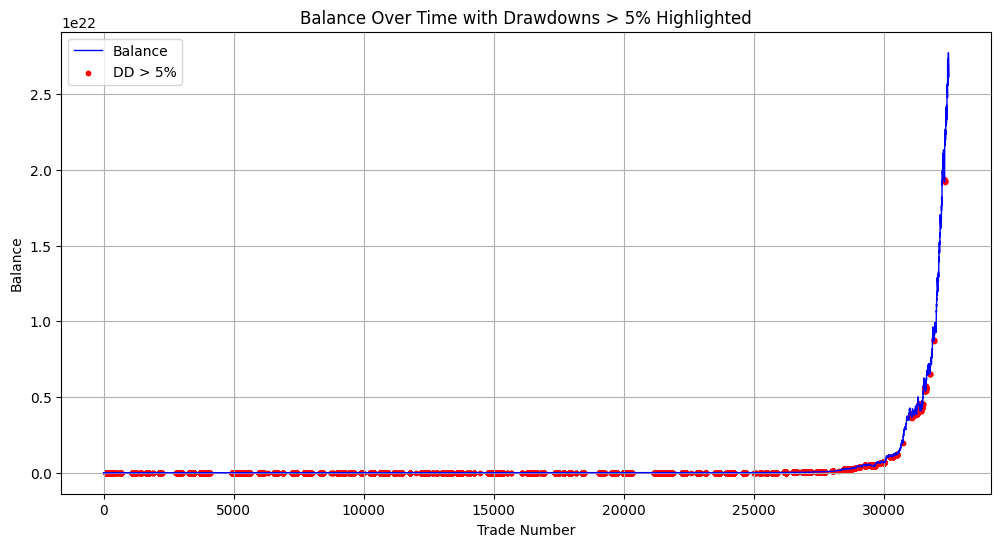

In [59]:
# Backtesting loop
for i in range(1, len(data) - 1):
    entry_date = data['Time'][i]

    # Skip trades outside of trading hours
    if not (TRADING_START_HOUR <= entry_date.hour < TRADING_END_HOUR):
        continue

    trade_type = None
    stop_loss, tp, entry_price, exit_price, position = None, None, None, None, None
    hit_tp, hit_sl = False, False  # Flags for SL/TP hit

    # Long entry condition
    if (
        data['Low'][i] <= data['LowerBB'][i] and
        data['Close'][i] > data['Open'][i] and
        data['StochRSI_K'][i] > data['StochRSI_D'][i]  # Bullish Stochastic RSI
    ):
        trade_type = 'Long'
        stop_loss = data['Low'][i]
        entry_price = data['Open'][i + 1]
        tp = entry_price + tp_multiplier * (entry_price - stop_loss)
        risk_amount = balance * risk_percent  # Use current balance for risk calculation
        position = position_size(balance, risk_amount, (entry_price - stop_loss) / entry_price)

    # Short entry condition
    elif (
        data['High'][i] >= data['UpperBB'][i] and
        data['Close'][i] < data['Open'][i] and
        data['StochRSI_K'][i] < data['StochRSI_D'][i]  # Bearish Stochastic RSI
    ):
        trade_type = 'Short'
        stop_loss = data['High'][i]
        entry_price = data['Open'][i + 1]
        tp = entry_price - tp_multiplier * (stop_loss - entry_price)
        risk_amount = balance * risk_percent  # Use current balance for risk calculation
        position = position_size(balance, risk_amount, (stop_loss - entry_price) / entry_price)

    if trade_type:
        logging.info(
            f"{trade_type} Entry: Entry Price: {entry_price}, Stop Loss: {stop_loss}, Take Profit: {tp}, "
            f"Position Size: {position:.4f}, Balance: {balance:.2f}, Entry Date: {entry_date}"
        )

        # Simulate exit on candle close
        for j in range(i + 1, len(data)):
            exit_date = data['Time'][j]
            if not (TRADING_START_HOUR <= exit_date.hour < TRADING_END_HOUR):
                continue

            if trade_type == 'Long':
                if data['Close'][j] >= tp:  # Take-profit hit
                    exit_price = tp
                    hit_tp = True
                    break
                elif data['Close'][j] <= stop_loss:  # Stop-loss hit
                    exit_price = stop_loss
                    hit_sl = True
                    break
            elif trade_type == 'Short':
                if data['Close'][j] <= tp:  # Take-profit hit
                    exit_price = tp
                    hit_tp = True
                    break
                elif data['Close'][j] >= stop_loss:  # Stop-loss hit
                    exit_price = stop_loss
                    hit_sl = True
                    break

        # If no SL/TP hit, exit at the final candle's close price
        if exit_price is None:
            exit_price = data['Close'][j]

        # Calculate profit/loss
        if trade_type == 'Long':
            profit = (exit_price - entry_price) * position
        elif trade_type == 'Short':
            profit = (entry_price - exit_price) * position

        balance += profit

        trade_history.append({
            'Entry': entry_price, 'Exit': exit_price, 'Profit': profit, 'Balance': balance,
            'Type': trade_type, 'Hit TP': hit_tp, 'Hit SL': hit_sl, 'Entry Date': entry_date, 'Exit Date': exit_date
        })

        logging.info(
            f"{trade_type} Exit: Exit Price: {exit_price}, Profit: {profit:.2f}, "
            f"Hit TP: {hit_tp}, Hit SL: {hit_sl}, Balance: {balance:.2f}, Exit Date: {exit_date}"
        )
# Convert trade history to DataFrame
trade_df = pd.DataFrame(trade_history)

# Save trade history to CSV
trade_df.to_csv('trade_history5.csv', index=False)

# Calculate peak balance and maximum drawdown
trade_df['Peak Balance'] = trade_df['Balance'].cummax()  # Running maximum balance
trade_df['Drawdown'] = trade_df['Peak Balance'] - trade_df['Balance']  # Drawdown per trade
trade_df['Drawdown %'] = (trade_df['Drawdown'] / trade_df['Peak Balance']) * 100

# Plot balance over time with drawdowns > 5% highlighted
dd_threshold = 9.0
plt.figure(figsize=(12, 6))
plt.plot(trade_df['Balance'], label='Balance', color='blue', linewidth=1)
plt.scatter(
    trade_df.index[trade_df['Drawdown %'] > dd_threshold],
    trade_df['Balance'][trade_df['Drawdown %'] > dd_threshold],
    color='red', label='DD > 5%', s=10
)
plt.title('Balance Over Time with Drawdowns > 5% Highlighted')
plt.xlabel('Trade Number')
plt.ylabel('Balance')
plt.legend()
plt.grid()
plt.show()





In [60]:
# Final Statistics
max_drawdown = trade_df['Drawdown'].max()
max_drawdown_pct = trade_df['Drawdown %'].max()
total_profit = trade_df['Profit'].sum()
final_balance = trade_df['Balance'].iloc[-1]
roi = (final_balance - initial_balance) / initial_balance * 100



In [61]:
# Add win rate calculation
winning_trades = len(trade_df[trade_df['Profit'] > 0])
total_trades = len(trade_df)
win_rate = (winning_trades / total_trades) * 100 if total_trades > 0 else 0  # Avoid division by zero



In [62]:
print(trade_df.describe())

              Entry          Exit        Profit       Balance  Peak Balance      Drawdown    Drawdown %
count  32499.000000  32499.000000  3.249900e+04  3.249900e+04  3.249900e+04  3.249900e+04  32499.000000
mean       1.068789      1.068765  8.052334e+17  5.492588e+20  5.697718e+20  2.051299e+19      5.977468
std        0.034158      0.034131  3.634318e+19  2.610674e+21  2.682020e+21  1.024687e+20      6.265731
min        0.954310      0.954030 -7.233128e+19  7.382466e+03  9.971811e+03  0.000000e+00      0.000000
25%        1.053510      1.053570 -1.157234e+15  7.285742e+08  7.348406e+08  5.183233e+06      1.587235
50%        1.076100      1.076050 -6.595744e+09  1.359432e+13  1.714951e+13  1.885621e+11      4.108853
75%        1.090720      1.090565 -9.253969e+04  1.178019e+18  1.188746e+18  3.029870e+16      8.238144
max        1.148460      1.148840  1.355833e+21  2.774263e+22  2.774263e+22  2.130342e+21     45.796371


In [63]:
# Calculate profitable and losing days
trade_df['Entry Date Only'] = trade_df['Entry Date'].dt.date
daily_profit = trade_df.groupby('Entry Date Only')['Profit'].sum()
profitable_days = len(daily_profit[daily_profit > 0])
losing_days = len(daily_profit[daily_profit < 0])



In [64]:
# Logging final summary
logging.info(f"Final Backtest Summary:")
logging.info(f"Initial Balance: {initial_balance:.2f}")
logging.info(f"Final Balance: {final_balance:.2f}")
logging.info(f"Total Profit: {total_profit:.2f}")
logging.info(f"ROI: {roi:.2f}%")
logging.info(f"Maximum Drawdown: {max_drawdown:.2f} ({max_drawdown_pct:.2f}%)")
logging.info(f"Win Rate: {win_rate:.2f}%")
logging.info(f"Profitable Days: {profitable_days}, Losing Days: {losing_days}")



In [65]:
# Print final summary to console
print("=== Final Backtest Summary ===")
print(f"Initial Balance: {initial_balance:.2f}")
print(f"Final Balance: {final_balance:.2f}")
print(f"Total Profit: {total_profit:.2f}")
print(f"ROI: {roi:.2f}%")
print(f"Maximum Drawdown: {max_drawdown:.2f} ({max_drawdown_pct:.2f}%)")
print(f"Win Rate: {win_rate:.2f}%")



=== Final Backtest Summary ===
Initial Balance: 10000.00
Final Balance: 26169279222385163108352.00
Total Profit: 26169279222385200857088.00
ROI: 261692792223851610112.00%
Maximum Drawdown: 2130342039038132748288.00 (45.80%)
Win Rate: 7.56%


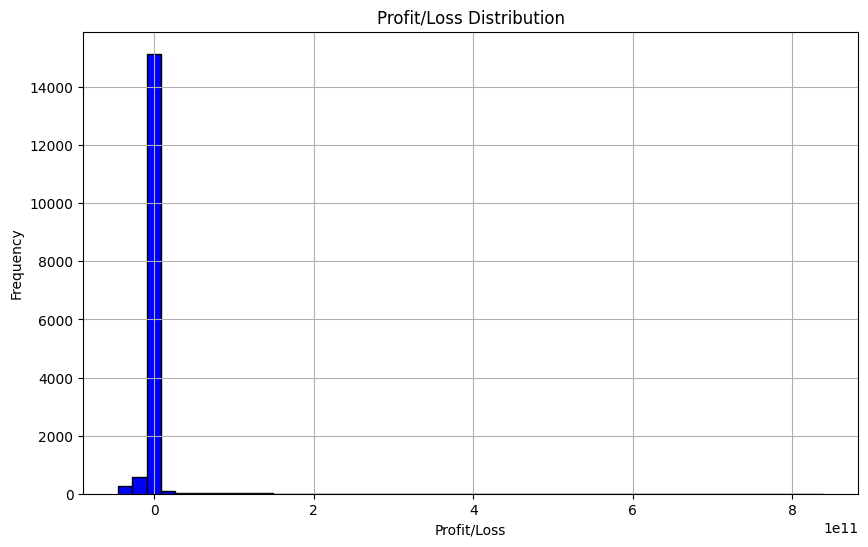

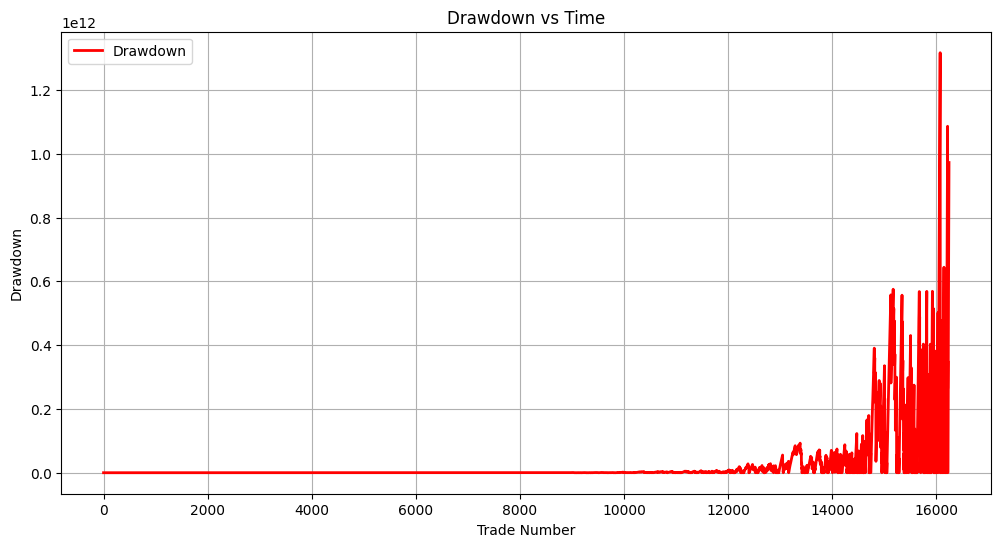

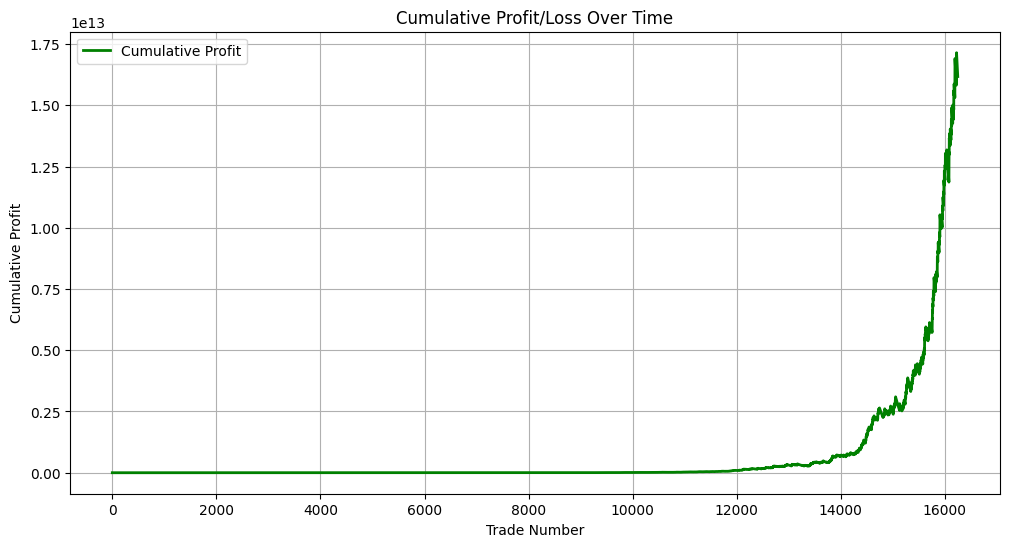

In [42]:

# Visualizations

# 1. Profit/Loss Distribution
plt.figure(figsize=(10, 6))
plt.hist(trade_df['Profit'], bins=50, color='blue', edgecolor='black')
plt.title('Profit/Loss Distribution')
plt.xlabel('Profit/Loss')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# 2. Drawdown vs Time
plt.figure(figsize=(12, 6))
plt.plot(trade_df['Drawdown'], label='Drawdown', color='red', linewidth=2)
plt.title('Drawdown vs Time')
plt.xlabel('Trade Number')
plt.ylabel('Drawdown')
plt.grid()
plt.legend()
plt.show()

# 3. Cumulative Profit/Loss
trade_df['Cumulative Profit'] = trade_df['Profit'].cumsum()
plt.figure(figsize=(12, 6))
plt.plot(trade_df['Cumulative Profit'], label='Cumulative Profit', color='green', linewidth=2)
plt.title('Cumulative Profit/Loss Over Time')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Profit')
plt.grid()
plt.legend()
plt.show()
